In [ ]:
#BEST MODEL IS ARIMA(P=3,Q=2,D=4) WITH RMSE 110.
#SARIMA COULD HAVE BEEN BETTER, BUT WAS TAKING A LOT OF TIME TO RUN AND TUNE THE SLIDERS OF p,q,d,P,Q,D

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import SimpleExpSmoothing
from ipywidgets import interact,widgets
from statsmodels.tsa.api import Holt, ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
df_train = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Train2.csv')

In [31]:
df_train.shape[0]

18288

In [32]:
trn=int(0.8*18288)
trn

14630

In [33]:
tst=int(0.2*18288)
tst

3657

In [34]:
y_train=df_train['Count'].iloc[:-trn]
y_train

,Count
0,8
1,2
2,6
3,2
4,2
...,...
3653,14
3654,12
3655,12
3656,16


In [35]:
y_test=df_train['Count'].iloc[-trn:]
y_train

,Count
0,8
1,2
2,6
3,2
4,2
...,...
3653,14
3654,12
3655,12
3656,16


<Axes: >

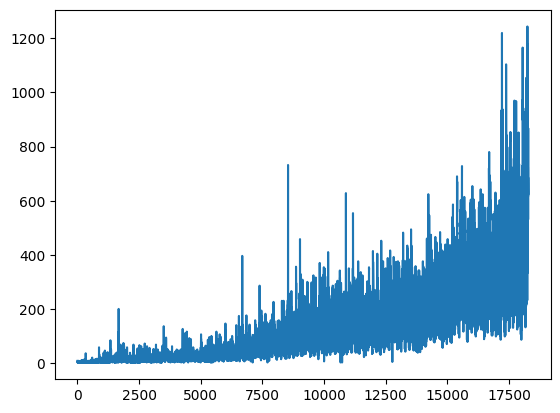

In [36]:
df_train['Count'].plot()

In [38]:
result=adfuller(df_train['Count'],maxlag=10)
print("P-Value = ",result[1])
if result[1]<0.05:
    print("Time series is Stationary")
else:
    print("Time series is Not Stationary")

P-Value =  6.730114049810995e-25
Time series is Stationary


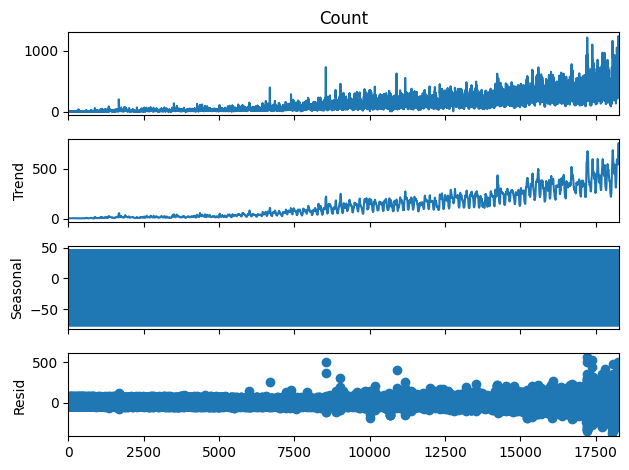

In [37]:
series=df_train["Count"]
result=seasonal_decompose(series,model='additive',period=24)
result.plot()
plt.show()

Trailing Mean Average

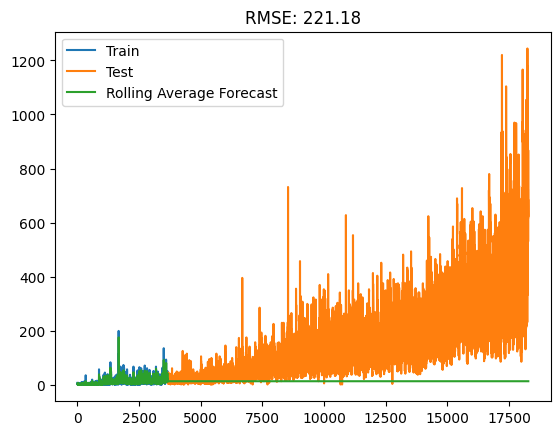

In [18]:
span=3
fcast=y_train.rolling(span).mean()
MA=fcast.iloc[-1]
MA_series=pd.Series(MA.repeat(len(y_test)))
MA_fcast=pd.concat([fcast,MA_series],ignore_index=True)
rmse=root_mean_squared_error(y_test,MA_series)
plt.title(f'RMSE: {rmse:.2f}')
plt.plot(y_train,label='Train')
plt.plot(y_test,label='Test')
plt.plot(MA_fcast,label='Rolling Average Forecast')
plt.legend(loc='best')
plt.show()

Simple Smoothing

In [21]:
ses=SimpleExpSmoothing(y_train)
def simp_exp(alpha):
    fit1=ses.fit(smoothing_level=alpha)
    fcast1=fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE: {rmse:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(simp_exp,alpha=(0.01,1,0.01))

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), Output()), _d…

<function __main__.simp_exp(alpha)>

Holt Linear Trend

In [23]:
holt=Holt(y_train)
def holt_linear(alpha,beta):
    fit1=holt.fit(smoothing_level=alpha,smoothing_trend=beta)
    fcast1=fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE: {rmse:.2f}, alpha={alpha:.2f}, beta={beta:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(holt_linear,alpha=(0.01,1,0.01),beta=(0.01,1,0.01))

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.holt_linear(alpha, beta)>

Holt's Exponential Trend

In [24]:
def holt_both(alpha,beta,exponentiality):
    holt=Holt(y_train,exponential=exponentiality)
    fit1=holt.fit(smoothing_trend=beta,smoothing_level=alpha)
    fcast1=fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE: {rmse:.2f}, alpha={alpha:.2f}, beta={beta:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(holt_both,alpha=(0.01,1,0.01),beta=(0.01,1,0.01),exponentiality=[True,False])

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.holt_both(alpha, beta, exponentiality)>

Holts Winters

In [25]:
def hw(alpha,beta,gamma,seasonality,periods=24):
    holt=ExponentialSmoothing(y_train,trend='add', seasonal=seasonality,seasonal_periods=periods)
    fit1=holt.fit(smoothing_trend=beta,smoothing_level=alpha,smoothing_seasonal=gamma)
    fcast1=fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE: {rmse:.2f}, alpha={alpha:.2f}, beta={beta:.2f}, gamma={gamma:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(hw,alpha=(0.01,1,0.01),beta=(0.01,1,0.01),gamma=(0.01,1,0.01),seasonality=['add','mul'])

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.hw(alpha, beta, gamma, seasonality, periods=24)>

ARIMA

In [40]:
def arima(p,q,d):
    model=ARIMA(y_train,order=(p,q,d))
    model_fit=model.fit()
    print('Coefficient: \n', model_fit.params)
    predictions=model_fit.predict(start=len(y_train),end=len(y_train)+len(y_test)-1)
    y_test.plot(color='purple',label='Test')
    predictions.plot(color='red',label='Forcast')
    rmse=root_mean_squared_error(y_test,predictions)
    plt.title(f"RMSE: {rmse:.5f}")
    plt.legend(loc='best')

widgets.interact(arima,p=(0,5,1),q=(0,5,1),d=(0,5,1))

interactive(children=(IntSlider(value=2, description='p', max=5), IntSlider(value=2, description='q', max=5), …

<function __main__.arima(p, q, d)>

In [ ]:
def sarima(p,q,d,P,Q,D,S):
    model=ARIMA(y_train,order=(p,q,d),seasonal_order=(P,Q,D,S))
    model_fit=model.fit()
    predictions=model_fit.predict(start=len(y_train),end=len(y_train)+len(y_test)-1)
    y_test.plot(color='purple',label='Test')
    predictions.plot(color='red',label='Forcast')
    rmse=root_mean_squared_error(y_test,predictions)
    plt.title(f"RMSE: {rmse:.5f}")
    plt.legend(loc='best')
    plt.show()
widgets.interact(sarima,p=(0,5,1),q=(0,5,1),d=(0,5,1),P=(0,5,1),Q=(0,5,1),D=(0,5,1),S=24)

In [45]:
best_dt_model=ARIMA(y_train,order=(3,2,4))
best_dt_model=best_dt_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [46]:
df_test=pd.read_csv('/content/drive/My Drive/Colab Notebooks/Test2.csv')
N_steps = len(df_test)
test_identifiers = df_test[['ID', 'Datetime']].copy()

# 2. Define Columns to Drop (Must match the training X drop list)
cols_to_drop = ['ID', 'Datetime']
# 3. Create the Raw Feature Matrix for Testing
X_test_raw = df_test.drop(columns=cols_to_drop)
final_predictions_series=best_dt_model.forecast(len(df_test))
final_predictions_array = final_predictions_series.values
final_predictions_array

array([ 18.05765606,  20.32013874,  22.70340788, ..., 154.9071843 ,
       154.93311513, 154.95686257])

In [49]:
soln=test_identifiers.copy()
soln=soln.drop(columns=['Datetime'])
soln['Count']=final_predictions_array
submission_file=soln.to_csv('solution.csv',index=False)
submission_file